<h1> Experiment reflection against photon frequency </h1>

In [3]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Lines / markers
    "lines.linewidth": 1.0,
    "lines.markersize": 4,

})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[1]
sys.path.append(str(project_root))

#Local imports
from benchmark_model.scripts_experiments.reflection_vs_frequency import run_reflection_vs_frequency

<h2> Execute the experiment </h2>

To assess the impact of the frequency window, we run the experiment six times. Each experiment corresponds to a given frequency window $[\Lambda_{\rm IR}, \Lambda_{\rm UV}]$

In [4]:
#Parameters of the simulation
param_photon_bis = {'delta_k': 0.05*np.pi, 'x_0': -25}  #the photon frequency will be varied in this experiment

param_atom = {'Omega_A': 10*np.pi, 'g_A': np.sqrt(np.pi/2), 'L': 100}

param_time_evol = {'T': 50, 'dt': 0.01}

#Define an array of frequencies around the cavity bare esonance
nb_freq = 21
omega_p_tab = np.linspace(param_atom['Omega_A'] - param_atom['g_A']**2, 
                          param_atom['Omega_A'] + param_atom['g_A']**2, nb_freq)

#Assess the curve of reflection vs frequency of different frequency windows
frequency_windows = [
    (0, 20*pi),
    (0, 14*pi),
    (8*pi, 14*pi),
    (9*pi, 11*pi),
]

Run the experiment  8 times for each frequency window

In [5]:
correction = False

for i in range(len(frequency_windows)):
    index_experiment = i+1
    print("Running frequency window number ", index_experiment, " out of ", len(frequency_windows))
    cutoffs = {'ir_cutoff': frequency_windows[i][0], 'uv_cutoff': frequency_windows[i][1]}
    #Run the experiment

    frequency_values, final_reflection_tab = run_reflection_vs_frequency(param_photon_bis, param_atom, param_time_evol, omega_p_tab, cutoffs, 
                                                                         index_experiment=index_experiment, correction=correction, progress=True)

Running frequency window number  1  out of  4


100%|██████████| 21/21 [00:14<00:00,  1.44it/s]


Running frequency window number  2  out of  4


100%|██████████| 21/21 [00:10<00:00,  1.94it/s]


Running frequency window number  3  out of  4


100%|██████████| 21/21 [00:05<00:00,  3.56it/s]


Running frequency window number  4  out of  4


100%|██████████| 21/21 [00:03<00:00,  5.60it/s]


<h2> Plot the results </h2>

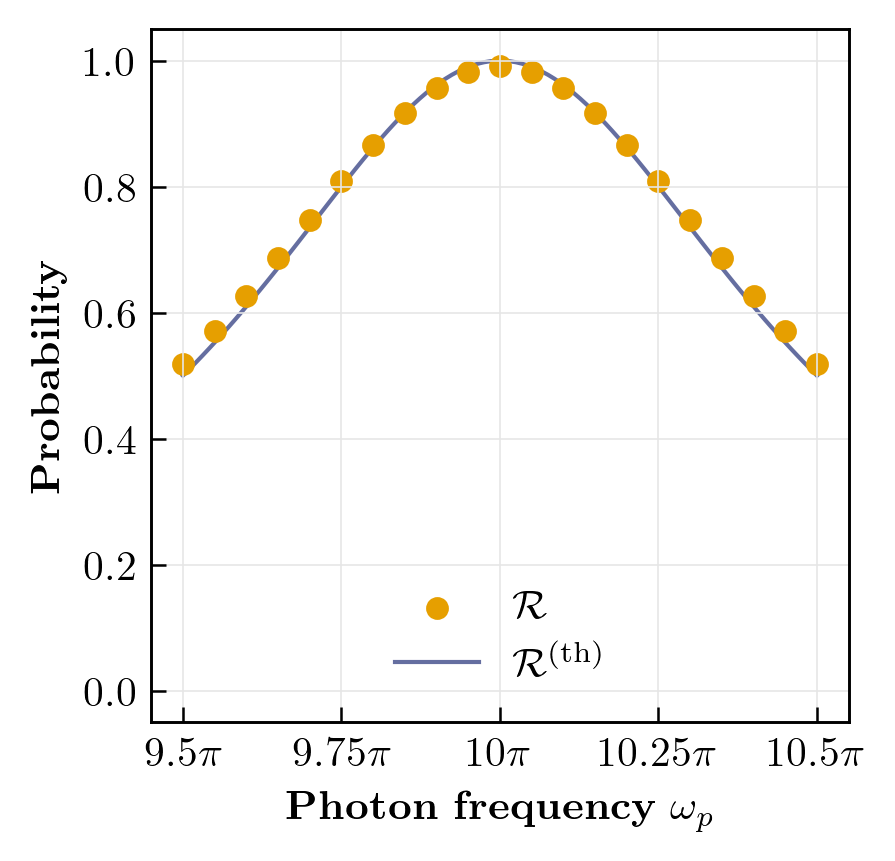

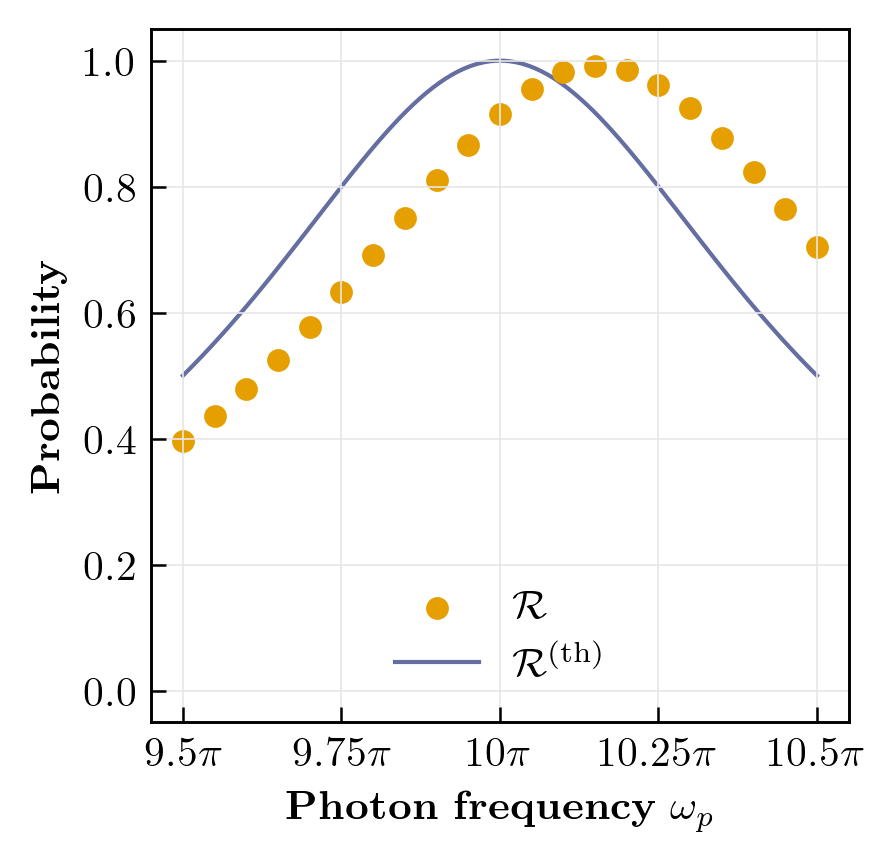

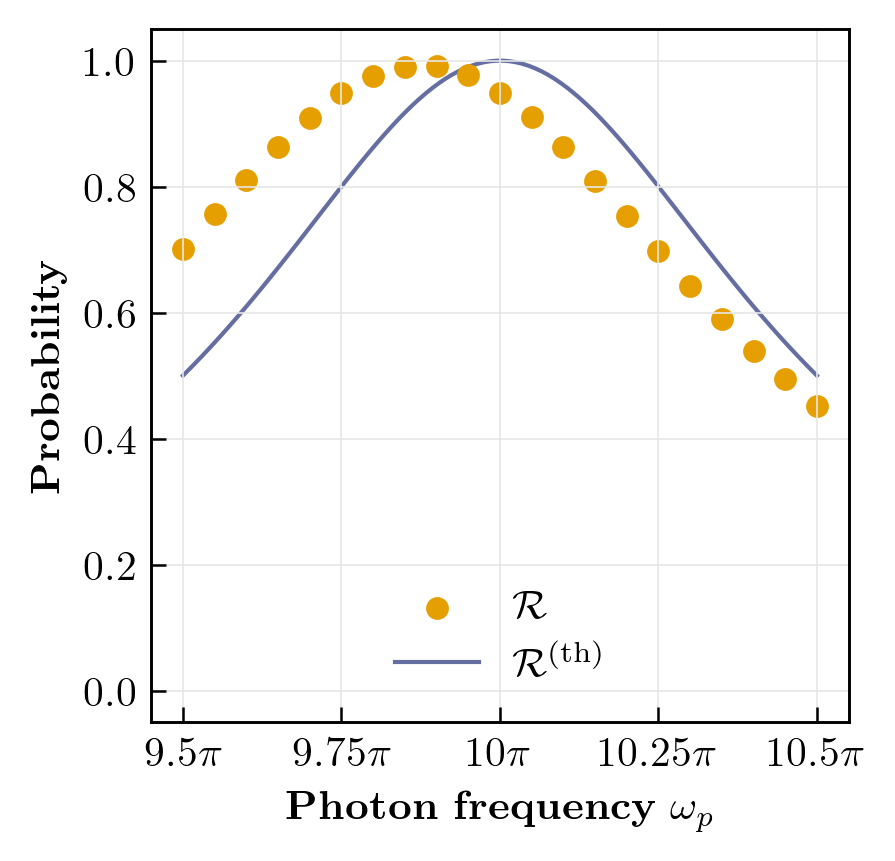

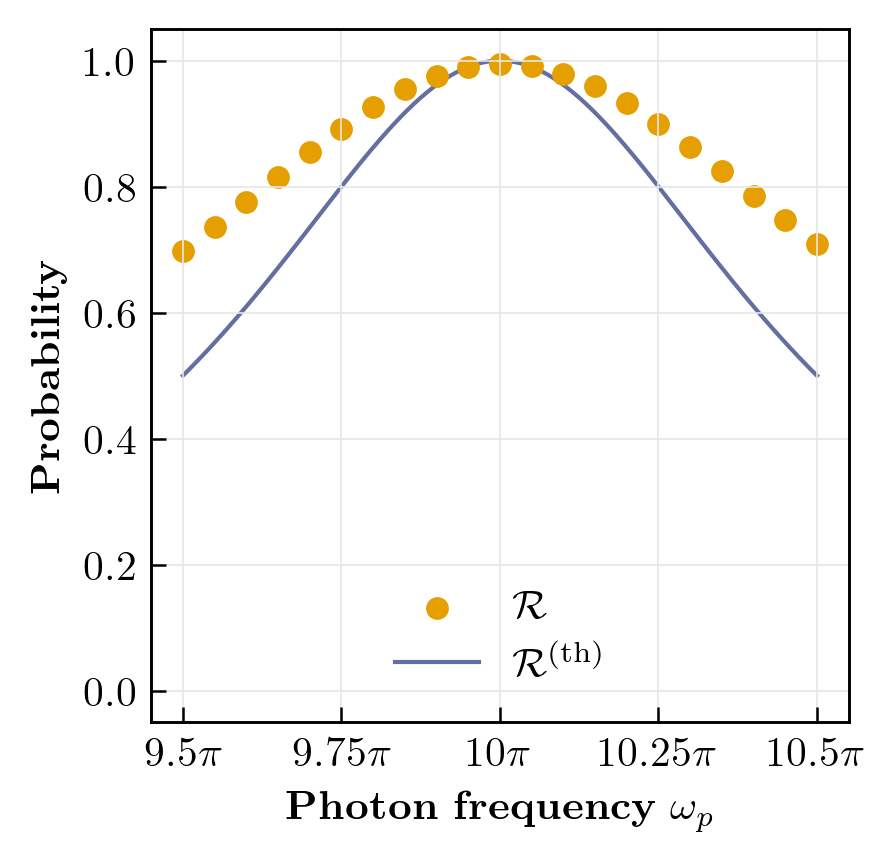

In [6]:
correction = False
show_fig = False

for index_experiment in [1,2,3,4]:

    ### Load the data 
    ir_cutoff = frequency_windows[index_experiment-1][0]
    uv_cutoff = frequency_windows[index_experiment-1][1]

    data_file = f"../results/csv_files/reflection_vs_frequency/reflection_vs_frequency_{index_experiment}_uncorrected.csv"
    df = pd.read_csv(data_file)
    photon_frequency_tab_uncorrected = df['photon_frequency_tab'].to_numpy()
    final_reflection_tab_uncorrected = df['final_reflection_tab'].to_numpy()

    if correction:
        data_file = f"../results/csv_files/reflection_vs_frequency/reflection_vs_frequency_{index_experiment}_corrected.csv"
        df = pd.read_csv(data_file)
        photon_frequency_tab_corrected = df['photon_frequency_tab'].to_numpy()
        final_reflection_tab_corrected = df['final_reflection_tab'].to_numpy()

    ###Generate the theoretical curve

    frequency_tab_theory = np.linspace(param_atom['Omega_A'] - param_atom['g_A']**2, param_atom['Omega_A'] + param_atom['g_A']**2, 100)
    #Bare prediction
    R_theory = 1 / (1 + ((frequency_tab_theory - param_atom['Omega_A'])/ (param_atom['g_A']**2))**2)


    ### Création de la figure

    fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

    color_bare = "#3E4A89"
    color_data = "#E69F00"
    color_data_corrected = "#009E73"

    #data points uncorrected
    ax.scatter(photon_frequency_tab_uncorrected, final_reflection_tab_uncorrected, label=r'$\mathcal{R}$', color=color_data, s=20)
    if correction:
        #data points corrected
        ax.scatter(photon_frequency_tab_corrected, final_reflection_tab_corrected, label=r'$\mathcal{R}^{(\rm corr)}$', color=color_data_corrected, s=20, marker="x")

    #theoretical curve
    ax.plot(frequency_tab_theory, R_theory, color=color_bare, alpha=0.8, zorder = -1, label=r'$\mathcal{R}^{(\rm th)}$')
    if correction:
        #Display a 5% error band around the theoretical curve
        ax.fill_between(frequency_tab_theory, 0.95*R_theory, 1.05*R_theory, color=color_bare, alpha=0.2, zorder = -2, label=r'$\pm 5\%$ error band')

    # Labels, limites et grille
    ax.set_xlabel(r'\textbf{Photon frequency} $\omega_p$', fontsize=10)
    ax.set_xticks([param_atom['Omega_A'] - param_atom['g_A']**2, 
                param_atom['Omega_A'] - param_atom['g_A']**2/2, 
                param_atom['Omega_A'], 
                param_atom['Omega_A'] + param_atom['g_A']**2/2, 
                param_atom['Omega_A'] + param_atom['g_A']**2])

    ax.set_xticklabels([r"$9.5\pi$",r"$9.75\pi$",r"$10\pi$",r"$10.25\pi$",r"$10.5\pi$"])

    ax.set_ylabel(r'\textbf{Probability}', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(color='0.9', linestyle='-', linewidth=0.4)

    # Légende sobre
    ax.legend(prop={'size': 10}, loc="lower center", frameon=False)

    #font size
    for item in [ax.xaxis.label, ax.yaxis.label]:
        item.set_fontsize(10)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(10)

    if correction:
        plt.savefig("../results/fig/reflection_multi_cutoff_experiment_"+str(index_experiment)+"_corrected.pdf", bbox_inches="tight")
    else:
        plt.savefig("../results/fig/reflection_multi_cutoff_experiment_"+str(index_experiment)+"_uncorrected.pdf", bbox_inches="tight")

    if show_fig:
        plt.show()